In [1]:
import pandas as pd

In [5]:
df = pd.read_csv(
    "../data/Feature Engineering_Marketing_campaign.csv",
    index_col=0
)

In [6]:
df.shape

(56000, 52)

In [7]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country', 'Age', 'Total_Spend',
       'Total_Purchases', 'Children', 'Age_Group', 'Family_Size',
       'Living_With', 'Customer_Tenure', 'Total_Accepted_Campaigns',
       'Customer_Segment', 'Purchase_Frequency', 'Web_Engagement', 'Is_Parent',
       'Income_Group', 'Engagement_Segment', 'Spending_Segment',
       'Response_Segment', 'Family_Segment', 'High_Value', 'Under_Served',
       'Deal_Seeker', 'Loyal_Customer', 'At_Risk', 'New_Customer'],
      dtype='object')

In [8]:
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

print(num_cols)

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Age',
       'Total_Spend', 'Total_Purchases', 'Children', 'Family_Size',
       'Customer_Tenure', 'Total_Accepted_Campaigns', 'Purchase_Frequency',
       'Web_Engagement', 'Is_Parent'],
      dtype='object')


In [9]:
exclude_cols = [
    'ID',
    'Year_Birth',
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Response',
    'Complain',
    'Is_Parent',
    'High_Value',
    'Under_Served',
    'Deal_Seeker',
    'Loyal_Customer',
    'At_Risk',
    'New_Customer'
]

num_cols = [
    col for col in num_cols
    if col not in exclude_cols
]

print(num_cols)

['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Age', 'Total_Spend', 'Total_Purchases', 'Children', 'Family_Size', 'Customer_Tenure', 'Total_Accepted_Campaigns', 'Purchase_Frequency', 'Web_Engagement']


In [10]:
for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = (
        Q1 - 1.5 * IQR
    )

    upper_bound = (
        Q3 + 1.5 * IQR
    )

    df[col] = df[col].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print(
    "Outliers handled successfully!"
)

Outliers handled successfully!


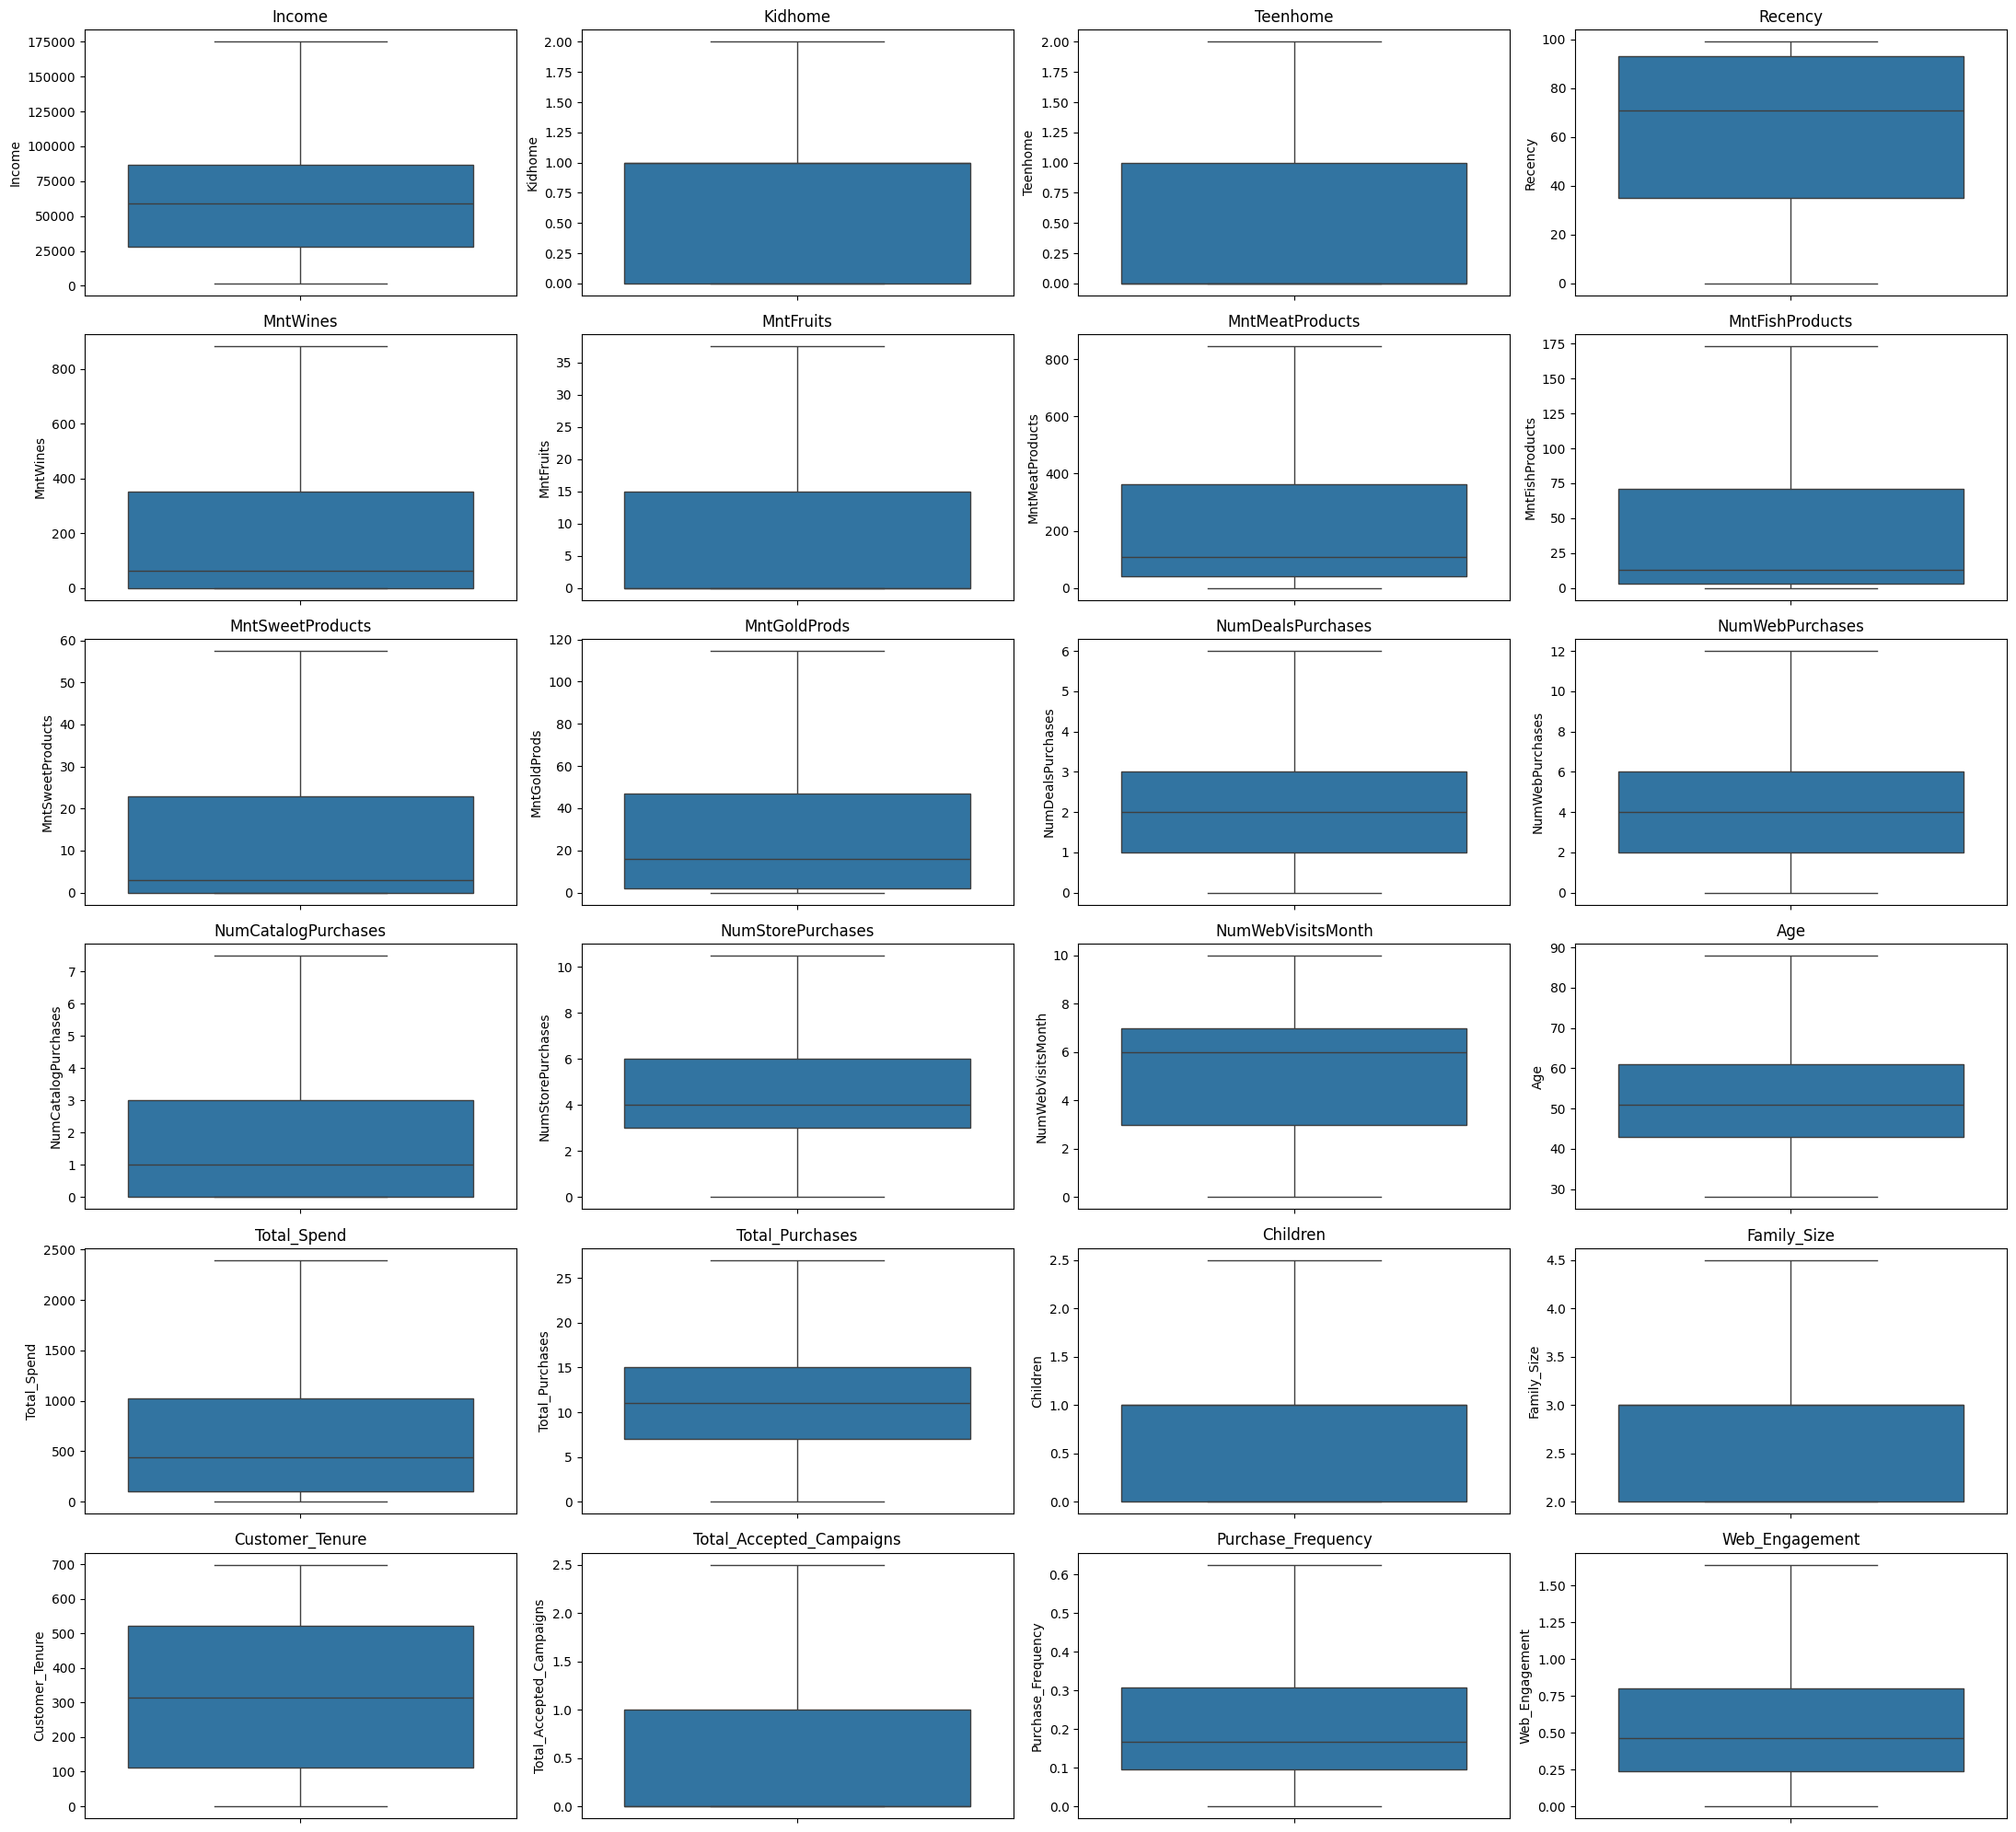

In [11]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 4
n_rows = math.ceil(
    len(num_cols) / n_cols
)

plt.figure(figsize=(22,20))

for i, col in enumerate(
    num_cols, 1
):
    plt.subplot(
        n_rows,
        n_cols,
        i
    )

    sns.boxplot(
        y=df[col]
    )

    plt.title(col)

plt.tight_layout()
plt.show()

In [12]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country', 'Age', 'Total_Spend',
       'Total_Purchases', 'Children', 'Age_Group', 'Family_Size',
       'Living_With', 'Customer_Tenure', 'Total_Accepted_Campaigns',
       'Customer_Segment', 'Purchase_Frequency', 'Web_Engagement', 'Is_Parent',
       'Income_Group', 'Engagement_Segment', 'Spending_Segment',
       'Response_Segment', 'Family_Segment', 'High_Value', 'Under_Served',
       'Deal_Seeker', 'Loyal_Customer', 'At_Risk', 'New_Customer'],
      dtype='object')

Univariate Analysis
(one variable at a Time)

In [13]:
num_cols = df.select_dtypes(
    include=['int64', 'float64']
).columns

print(num_cols)

Index(['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency',
       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts',
       'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
       'AcceptedCmp1', 'AcceptedCmp2', 'Response', 'Complain', 'Age',
       'Total_Spend', 'Total_Purchases', 'Children', 'Family_Size',
       'Customer_Tenure', 'Total_Accepted_Campaigns', 'Purchase_Frequency',
       'Web_Engagement', 'Is_Parent'],
      dtype='object')


Numerical Features Distribution

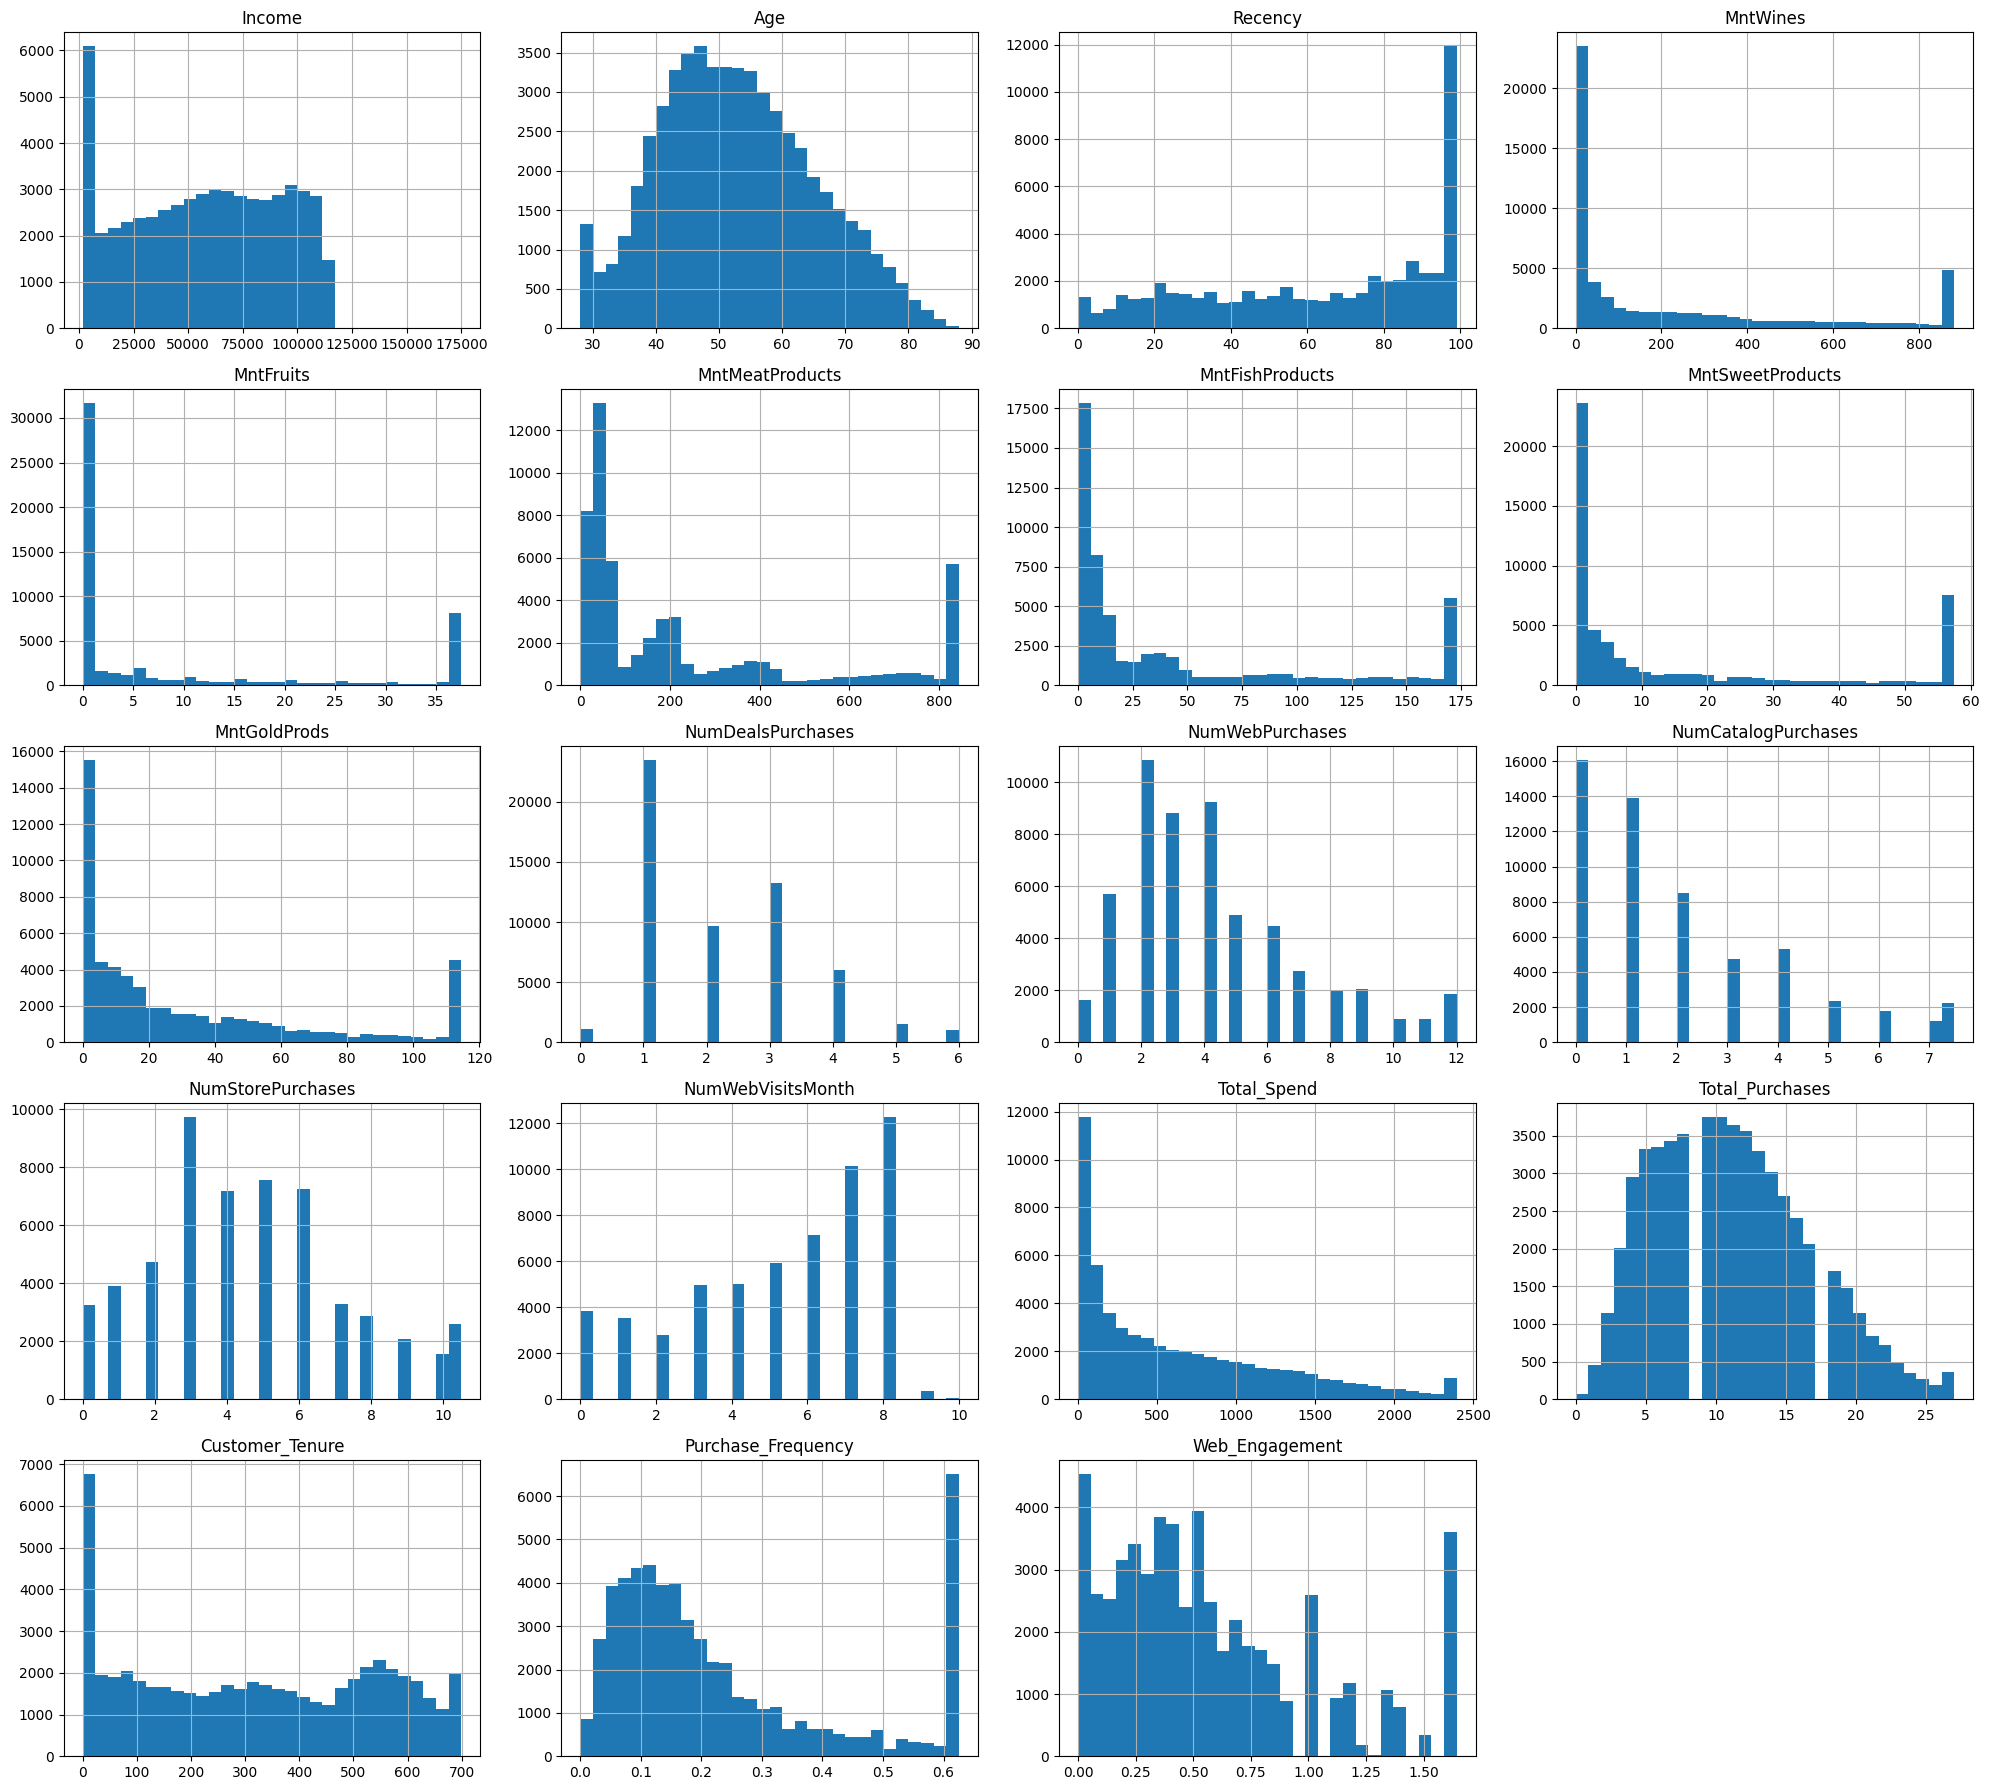

In [14]:
import matplotlib.pyplot as plt

num_cols = [
    'Income',
    'Age',
    'Recency',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumDealsPurchases',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth',
    'Total_Spend',
    'Total_Purchases',
    'Customer_Tenure',
    'Purchase_Frequency',
    'Web_Engagement'
]

df[num_cols].hist(
    figsize=(20,18),
    bins=30
)

plt.tight_layout()
plt.show()

EDA Distribution Analysis –  Conclusions
Demographics

Age → Normal distribution, 35–65 peak. Mature customer base.
Income → Right-skewed with outliers ~175K. Mostly middle-income customers.

Spending Behavior

MntWines → Heavily right-skewed — most spend ₹0, but high spenders exist (till 800+). Wine is a niche category.
MntMeatProducts → Similar pattern — small group spends heavily (800+).
MntFruits, MntFishProducts, MntSweetProducts, MntGoldProds → All heavily zero-inflated. Low engagement overall.
Total_Spend → Right-skewed → majority are low spenders; clear high-value customer segment exists.

 Purchase Channels

NumStorePurchases → Most active channel (peaks at 3–5 purchases).
NumWebPurchases → Moderate, peaks at 2–4.
NumCatalogPurchases → Low usage overall.
NumDealsPurchases → Most customers use 1–2 deals; deal-hunters are rare.

Engagement

NumWebVisitsMonth → Peaks at 6–8 visits/month — high web traffic but not converting equally.
Web_Engagement → Mostly low (0–0.5 range) with a spike near 1.5 — two distinct engagement groups visible.
Recency → Spike near 100 → large group of lapsed/inactive customers who haven't purchased recently.

Tenure & Frequency

Customer_Tenure → Bimodal — new customers + long-term loyalists both present.
Purchase_Frequency → Heavily skewed toward 0.6 → most customers cluster around one purchase frequency level.

In [16]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)

Index(['Education', 'Marital_Status', 'Dt_Customer', 'Country', 'Age_Group',
       'Living_With', 'Customer_Segment', 'Income_Group', 'Engagement_Segment',
       'Spending_Segment', 'Response_Segment', 'Family_Segment'],
      dtype='object')


In [17]:
cat_cols = [
    'Education', 'Marital_Status', 'Dt_Customer', 'Country',
    'Age_Group', 'Living_With', 'Customer_Segment',
    'Income_Group', 'Engagement_Segment', 'Spending_Segment',
    'Response_Segment', 'Family_Segment'
]

df[cat_cols].info()
df[cat_cols].isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 56000 entries, 0 to 55999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Education           56000 non-null  object
 1   Marital_Status      56000 non-null  object
 2   Dt_Customer         56000 non-null  object
 3   Country             56000 non-null  object
 4   Age_Group           56000 non-null  object
 5   Living_With         56000 non-null  object
 6   Customer_Segment    56000 non-null  object
 7   Income_Group        56000 non-null  object
 8   Engagement_Segment  56000 non-null  object
 9   Spending_Segment    56000 non-null  object
 10  Response_Segment    56000 non-null  object
 11  Family_Segment      56000 non-null  object
dtypes: object(12)
memory usage: 5.6+ MB


Education             0
Marital_Status        0
Dt_Customer           0
Country               0
Age_Group             0
Living_With           0
Customer_Segment      0
Income_Group          0
Engagement_Segment    0
Spending_Segment      0
Response_Segment      0
Family_Segment        0
dtype: int64

In [ ]:
#check the unique value Category Size
for col in cat_cols:
    print(col, ":", df[col].nunique())

Education : 5
Marital_Status : 2
Dt_Customer : 700
Country : 8
Age_Group : 4
Living_With : 2
Customer_Segment : 3
Income_Group : 5
Engagement_Segment : 2
Spending_Segment : 3
Response_Segment : 2
Family_Segment : 2


Low cardinality(Marital_Status,Marital_Status,Engagement_Segment,Response_Segment ,Family_Segment)
High cardinality(Dt_Customer)

In [19]:
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts())


 Education
Education
Graduation    22741
PhD           12581
Master        10530
2n Cycle       5966
Basic          4182
Name: count, dtype: int64

 Marital_Status
Marital_Status
Partner    31389
Alone      24611
Name: count, dtype: int64

 Dt_Customer
Dt_Customer
2014-06-29    4922
2012-07-30    1185
2012-12-21     116
2012-11-25     114
2012-12-28     109
              ... 
2012-08-04      29
2012-08-23      28
2012-08-05      27
2012-08-07      22
2012-08-06      21
Name: count, Length: 700, dtype: int64

 Country
Country
Spain           16703
Canada          10746
Saudi Arabia     8422
Australia        5677
India            4814
Germany          4432
USA              4331
Mexico            875
Name: count, dtype: int64

 Age_Group
Age_Group
Middle_Age       23799
Adult            16228
Senior           14330
ChildrenYoung     1643
Name: count, dtype: int64

 Living_With
Living_With
Partner    31389
Alone      24611
Name: count, dtype: int64

 Customer_Segment
Customer_Segment
Norm

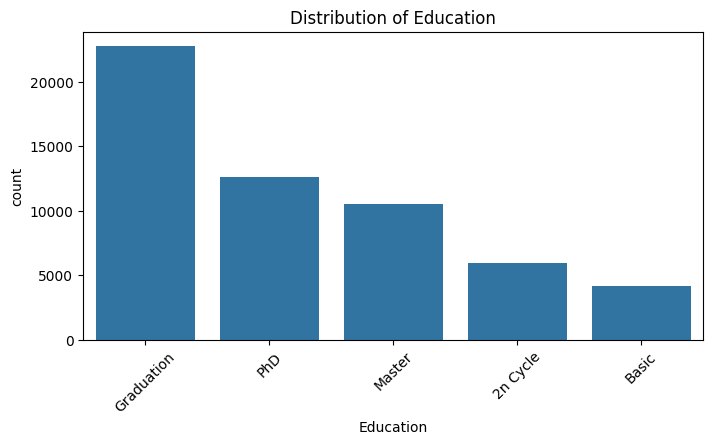

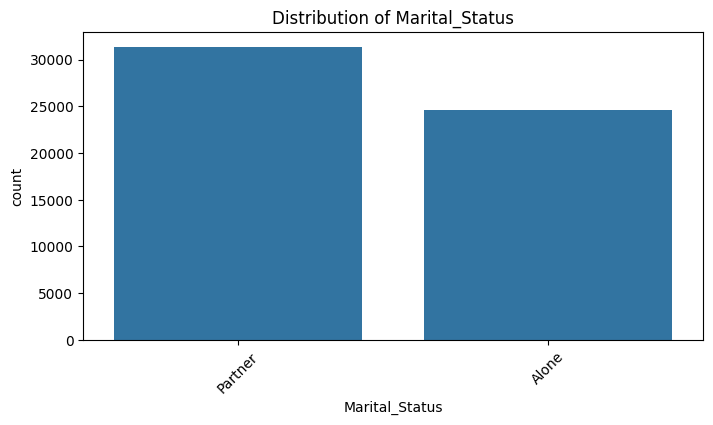

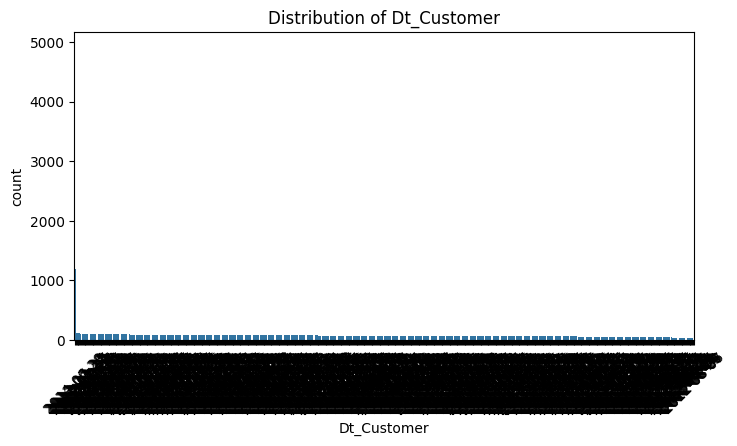

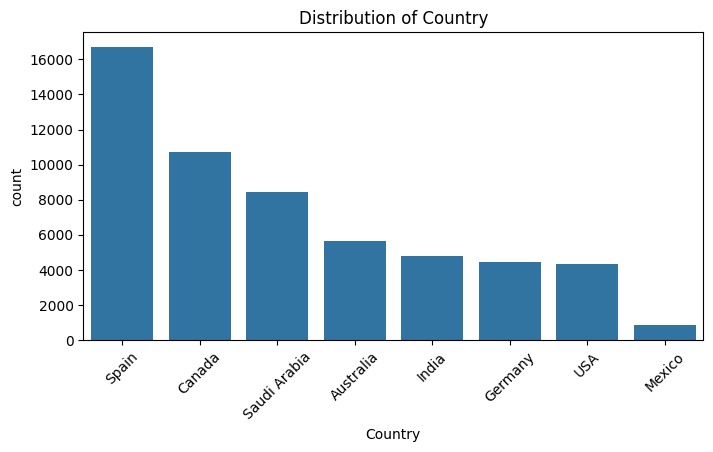

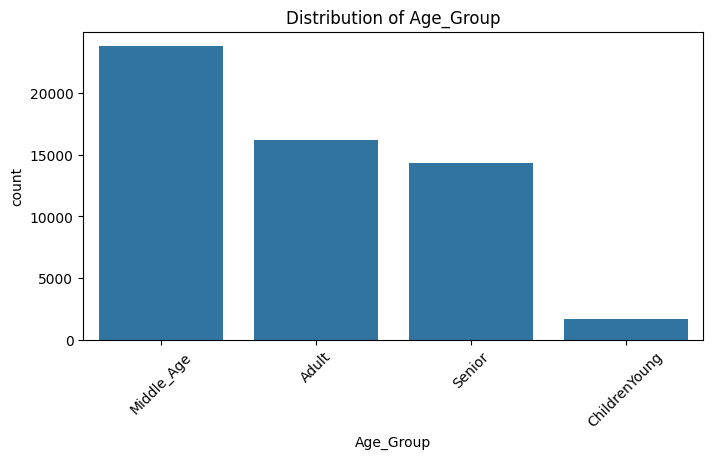

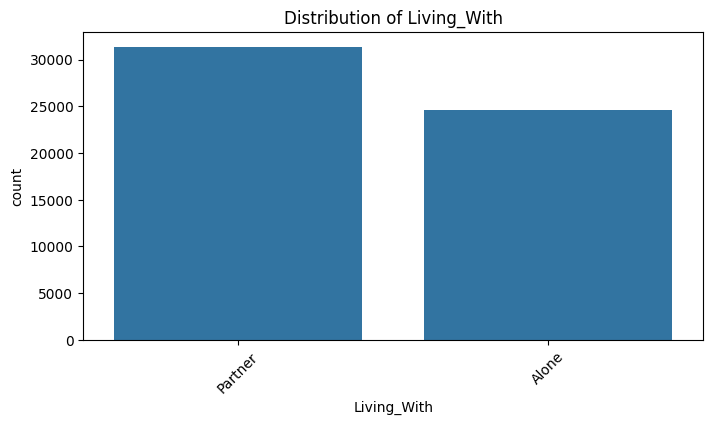

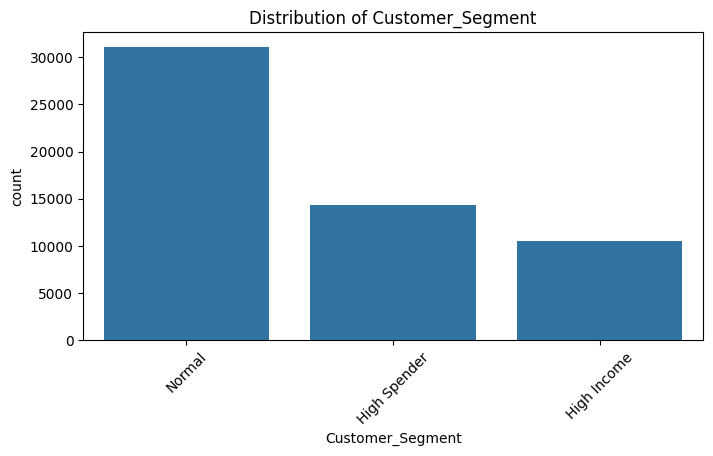

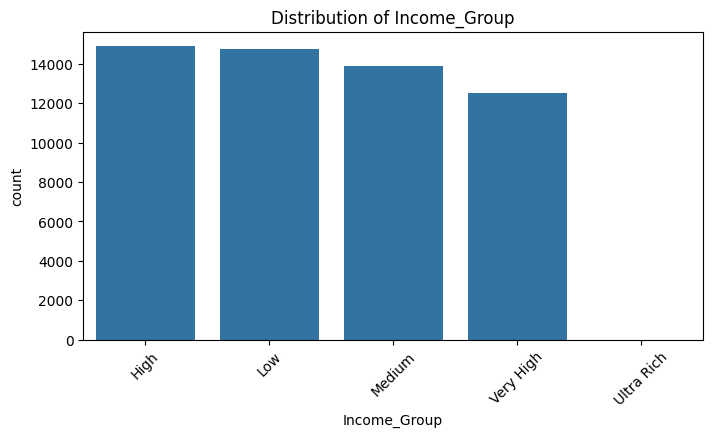

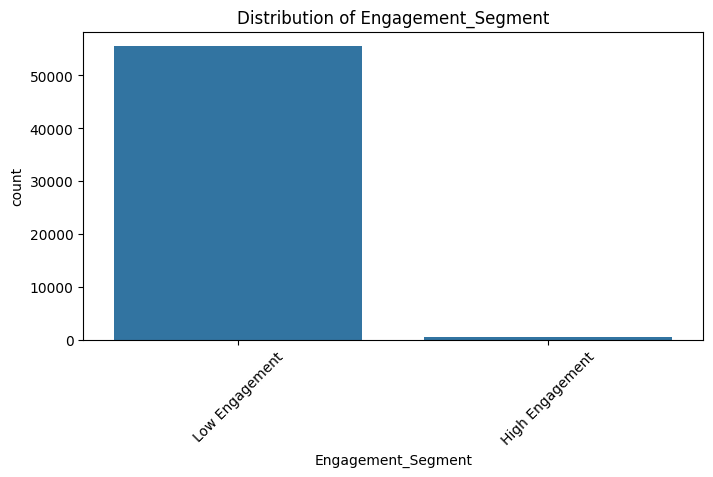

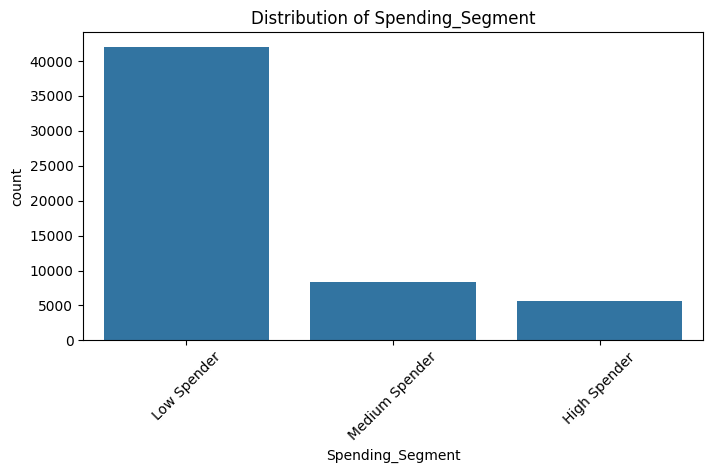

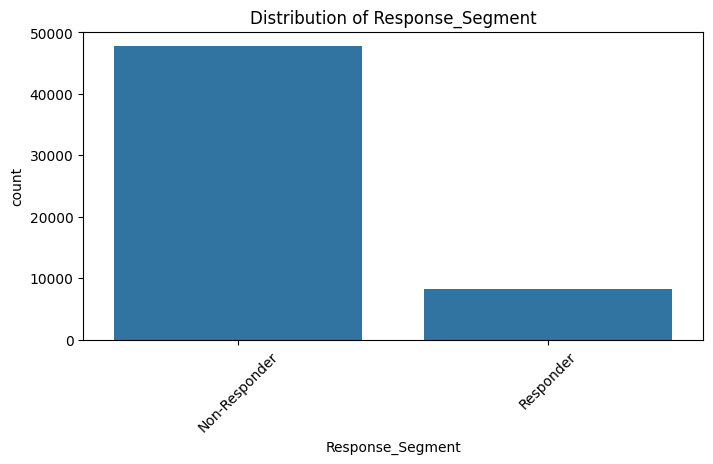

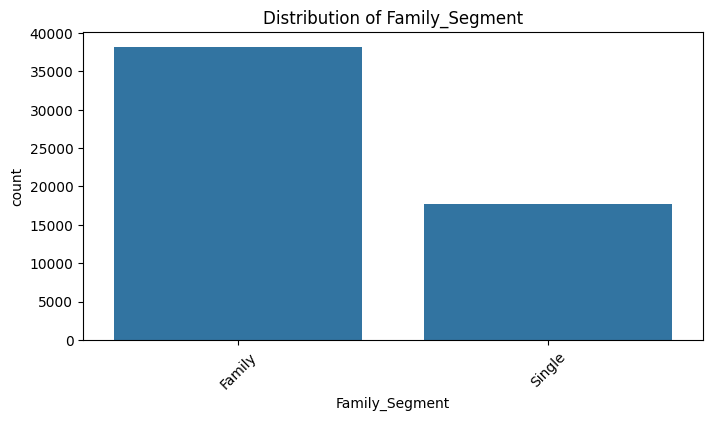

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

In [23]:
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts(normalize=True) * 100)


 Education
Education
Graduation    40.608929
PhD           22.466071
Master        18.803571
2n Cycle      10.653571
Basic          7.467857
Name: proportion, dtype: float64

 Marital_Status
Marital_Status
Partner    56.051786
Alone      43.948214
Name: proportion, dtype: float64

 Dt_Customer
Dt_Customer
2014-06-29    8.789286
2012-07-30    2.116071
2012-12-21    0.207143
2012-11-25    0.203571
2012-12-28    0.194643
                ...   
2012-08-04    0.051786
2012-08-23    0.050000
2012-08-05    0.048214
2012-08-07    0.039286
2012-08-06    0.037500
Name: proportion, Length: 700, dtype: float64

 Country
Country
Spain           29.826786
Canada          19.189286
Saudi Arabia    15.039286
Australia       10.137500
India            8.596429
Germany          7.914286
USA              7.733929
Mexico           1.562500
Name: proportion, dtype: float64

 Age_Group
Age_Group
Middle_Age       42.498214
Adult            28.978571
Senior           25.589286
ChildrenYoung     2.933929
Name

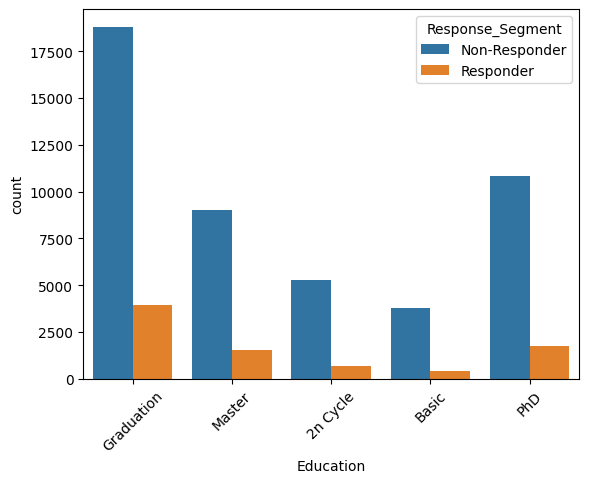

In [24]:
#Target relation analysis (VERY IMPORTANT)
sns.countplot(data=df, x='Education', hue='Response_Segment')
plt.xticks(rotation=45)
plt.show()

As know the graph Graduation person respond more than others and basis is Basic is Lower Responder

In [25]:
#Cross tab analysis
pd.crosstab(df['Education'], df['Response_Segment'], normalize='index') * 100

Response_Segment,Non-Responder,Responder
Education,,
2n Cycle,88.451224,11.548776
Basic,90.722143,9.277857
Graduation,82.700849,17.299151
Master,85.650522,14.349478
PhD,86.145775,13.854225


In [27]:
#Dt_Customer special handling
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

df['Year'] = df['Dt_Customer'].dt.year
df['Month'] = df['Dt_Customer'].dt.month

<Axes: xlabel='Year', ylabel='count'>

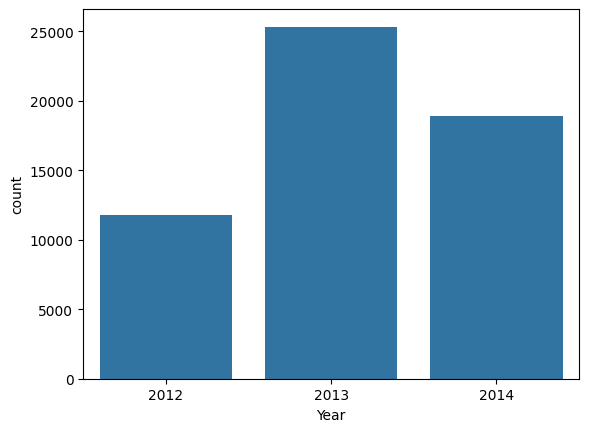

In [28]:
sns.countplot(data=df, x='Year')

#UNIVARIATE ANALYSIS (Single Variable)
Numerical Features Distribution


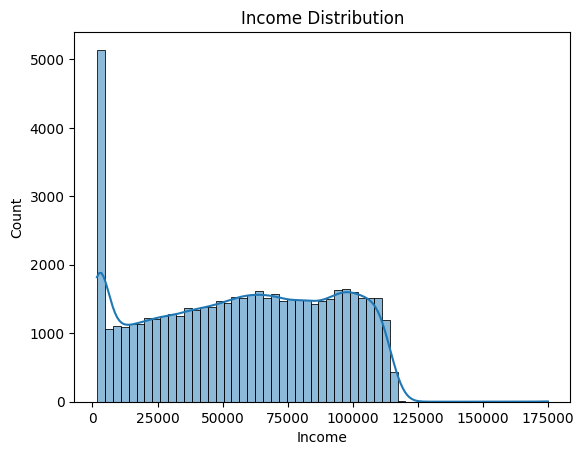

In [29]:
#Income
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Income'], kde=True)
plt.title("Income Distribution")
plt.show()

Insight:

Income is usually right-skewed
Few high-income outliers exist
Most customers belong to middle-income group

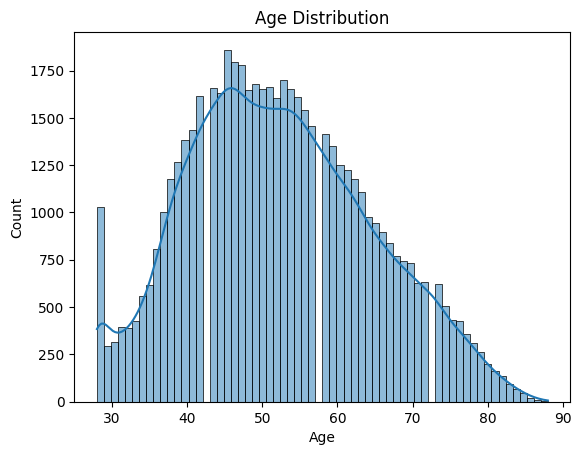

In [30]:
#Age (derived feature)
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

Insight:

Majority customers are middle-aged (30–60)
Very few young customers
Useful for targeting campaigns

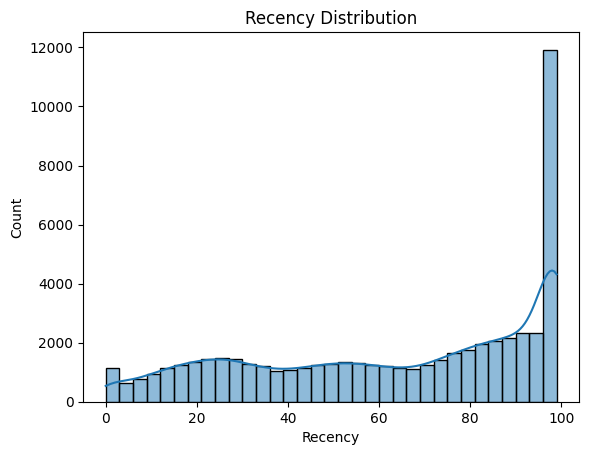

In [31]:
#Recency
sns.histplot(df['Recency'], kde=True)
plt.title("Recency Distribution")
plt.show()

insight:

High recency → inactive customers
Low recency → active customers
Most customers are moderately active

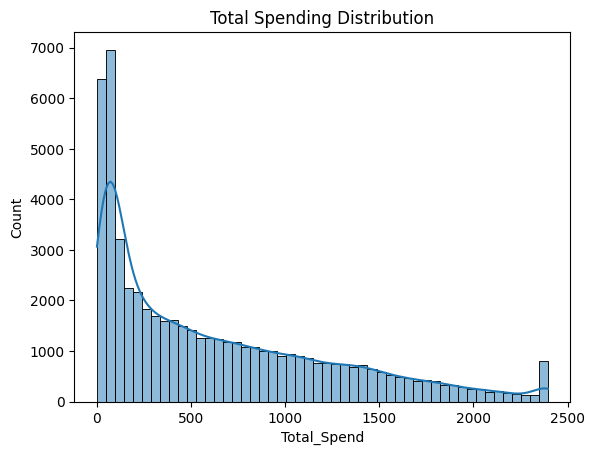

In [32]:
#Total Spend
sns.histplot(df['Total_Spend'], kde=True)
plt.title("Total Spending Distribution")
plt.show()

Insight:

Strong right skew
Few high spenders (VIP customers)
Most customers are low-medium spenders

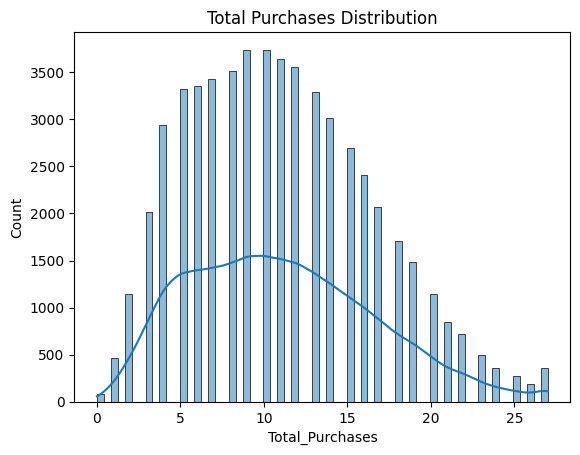

In [33]:
#Total Purchases
sns.histplot(df['Total_Purchases'], kde=True)
plt.title("Total Purchases Distribution")
plt.show()

Insight:

Small group of frequent buyers
Majority are low-frequency buyers

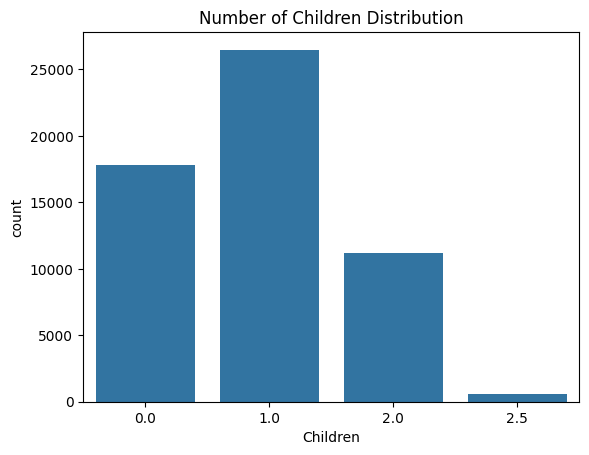

In [34]:
#Children / Family Structure
sns.countplot(x=df['Children'])
plt.title("Number of Children Distribution")
plt.show()

Insight:

Most customers have 0–1 children
Family size affects spending behavior

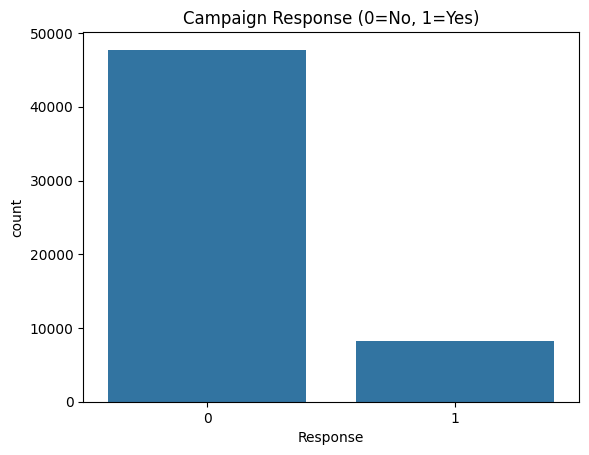

In [35]:
#Campaign Acceptance
sns.countplot(x=df['Response'])
plt.title("Campaign Response (0=No, 1=Yes)")
plt.show()

Insight:

Imbalanced dataset (few responders)
Important for classification problem

BIVARIATE ANALYSIS (2 Variables)

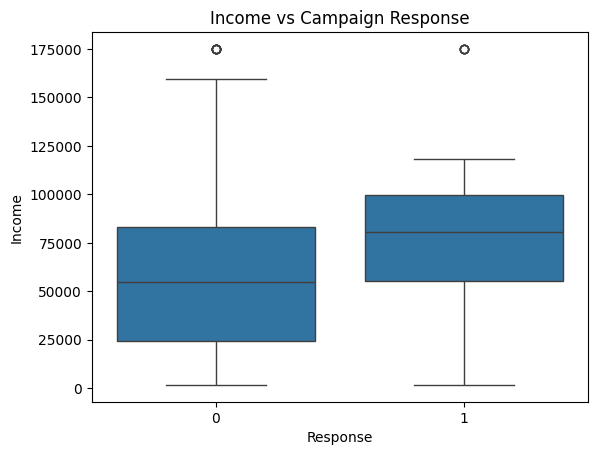

In [36]:
#(A) Income vs Response
sns.boxplot(data=df, x='Response', y='Income')
plt.title("Income vs Campaign Response")
plt.show()

Insight:

Responders often have higher income
Income is a strong predictor of response

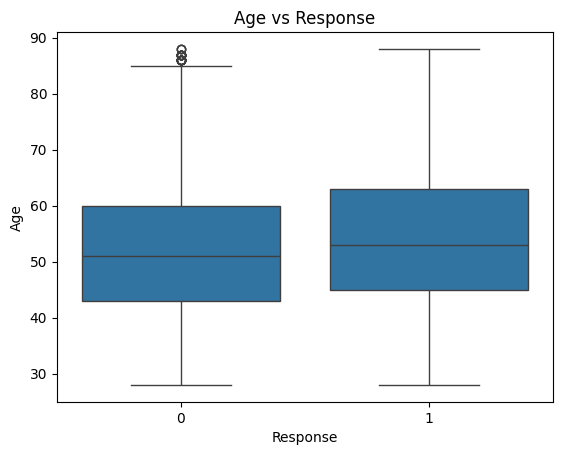

In [37]:
#Age vs Response
sns.boxplot(data=df, x='Response', y='Age')
plt.title("Age vs Response")
plt.show()

Insight:

Middle-aged customers respond more
Very young/old customers less responsive

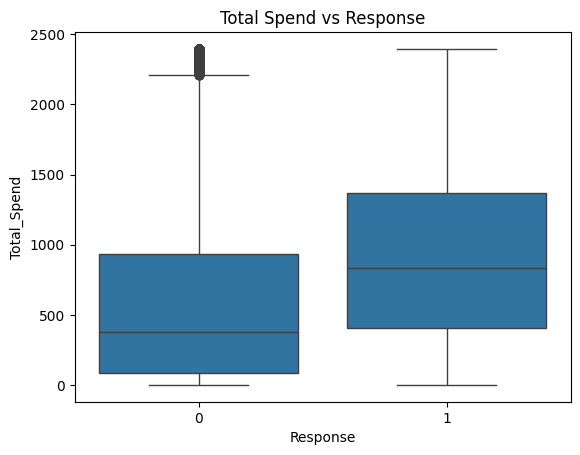

In [38]:
#Spending vs Response
sns.boxplot(data=df, x='Response', y='Total_Spend')
plt.title("Total Spend vs Response")
plt.show()

Insight:

High spenders are more likely to respond
Spending behavior is strong indicator

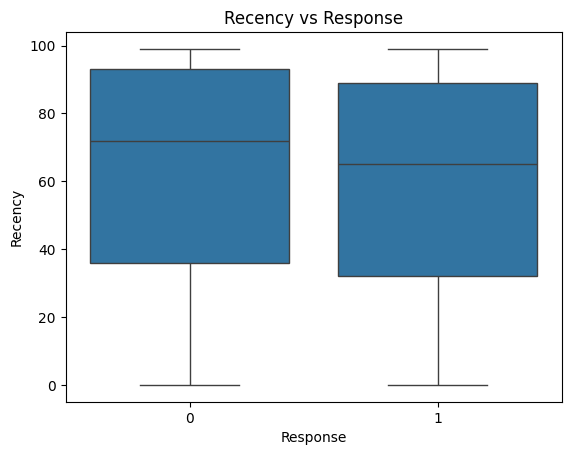

In [39]:
#Recency vs Response
sns.boxplot(data=df, x='Response', y='Recency')
plt.title("Recency vs Response")
plt.show()

nsight:

Low recency → high response probability
Recently active customers convert more

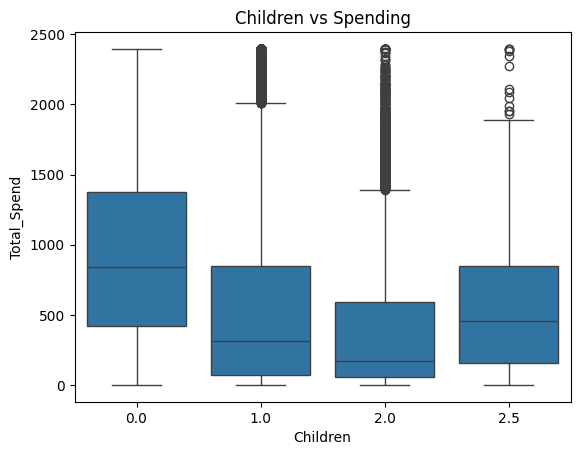

In [40]:
#Children vs Spending
sns.boxplot(data=df, x='Children', y='Total_Spend')
plt.title("Children vs Spending")
plt.show()

Insight:

More children → less spending
Family size negatively affects luxury spendi

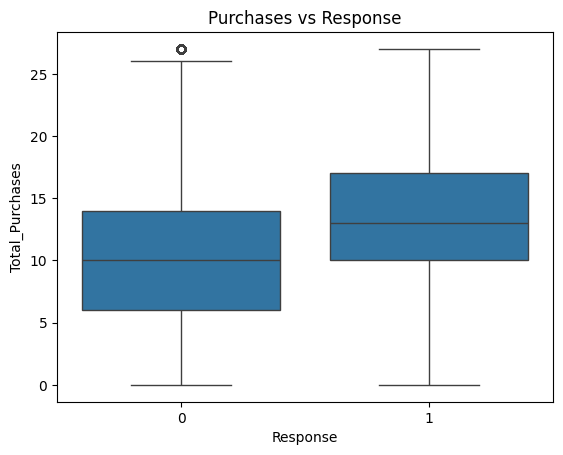

In [41]:
#Campaign Acceptance vs Spending
sns.boxplot(data=df, x='Response', y='Total_Purchases')
plt.title("Purchases vs Response")
plt.show()

Insight:

Frequent buyers respond more
Purchase activity = engagement strength

3. MULTIVARIATE ANALYSIS (3+ variables)

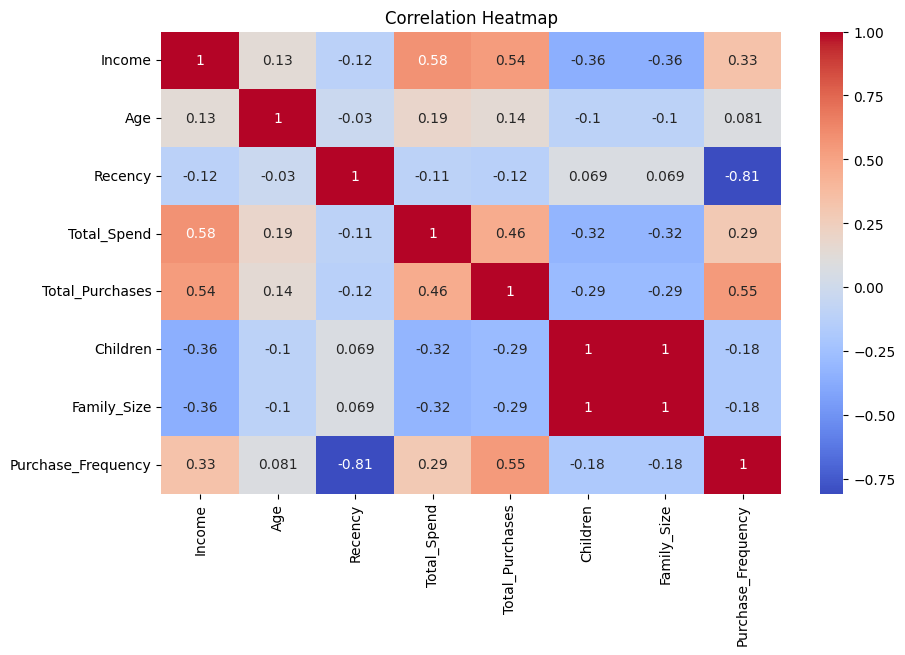

In [42]:
num_cols = [
    'Income', 'Age', 'Recency', 'Total_Spend',
    'Total_Purchases', 'Children', 'Family_Size',
    'Purchase_Frequency'
]

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Insight:

Total_Spend strongly correlated with Total_Purchases
Income moderately related to spending
Children negatively correlated with spending

#Income + Spend + Response

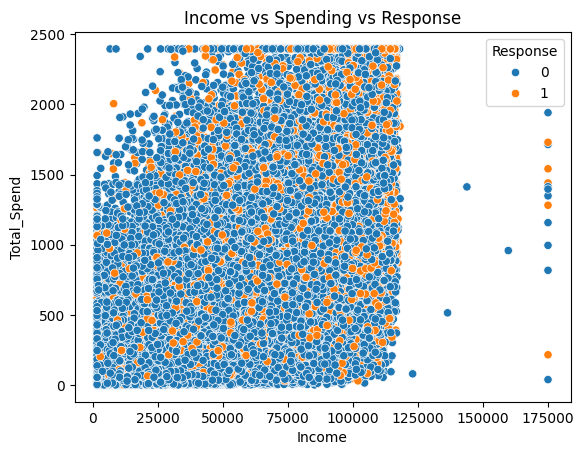

In [43]:
sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spend',
    hue='Response'
)
plt.title("Income vs Spending vs Response")
plt.show()

Insight:

High income + high spending → high response probability
Best customer segment identified

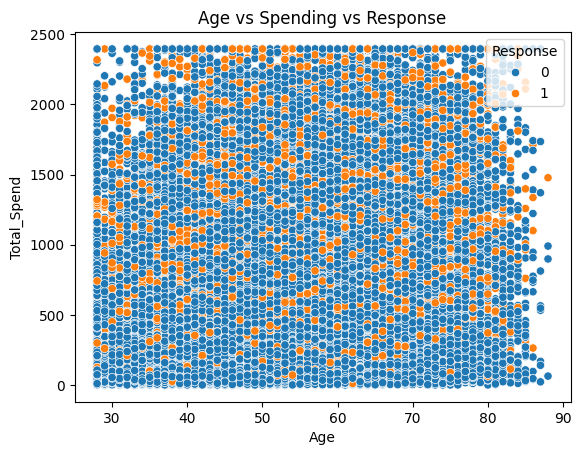

In [44]:
#Age + Spending + Response
sns.scatterplot(
    data=df,
    x='Age',
    y='Total_Spend',
    hue='Response'
)
plt.title("Age vs Spending vs Response")
plt.show()

Insight:

Middle-aged high spenders respond most
Age is a segmentation factor

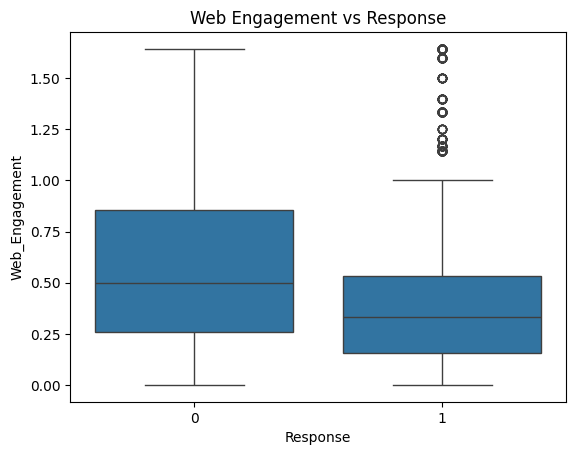

In [45]:
#Web Engagement + Response
sns.boxplot(data=df, x='Response', y='Web_Engagement')
plt.title("Web Engagement vs Response")
plt.show()

Insight:

Higher web engagement → more response
Digital behavior matters

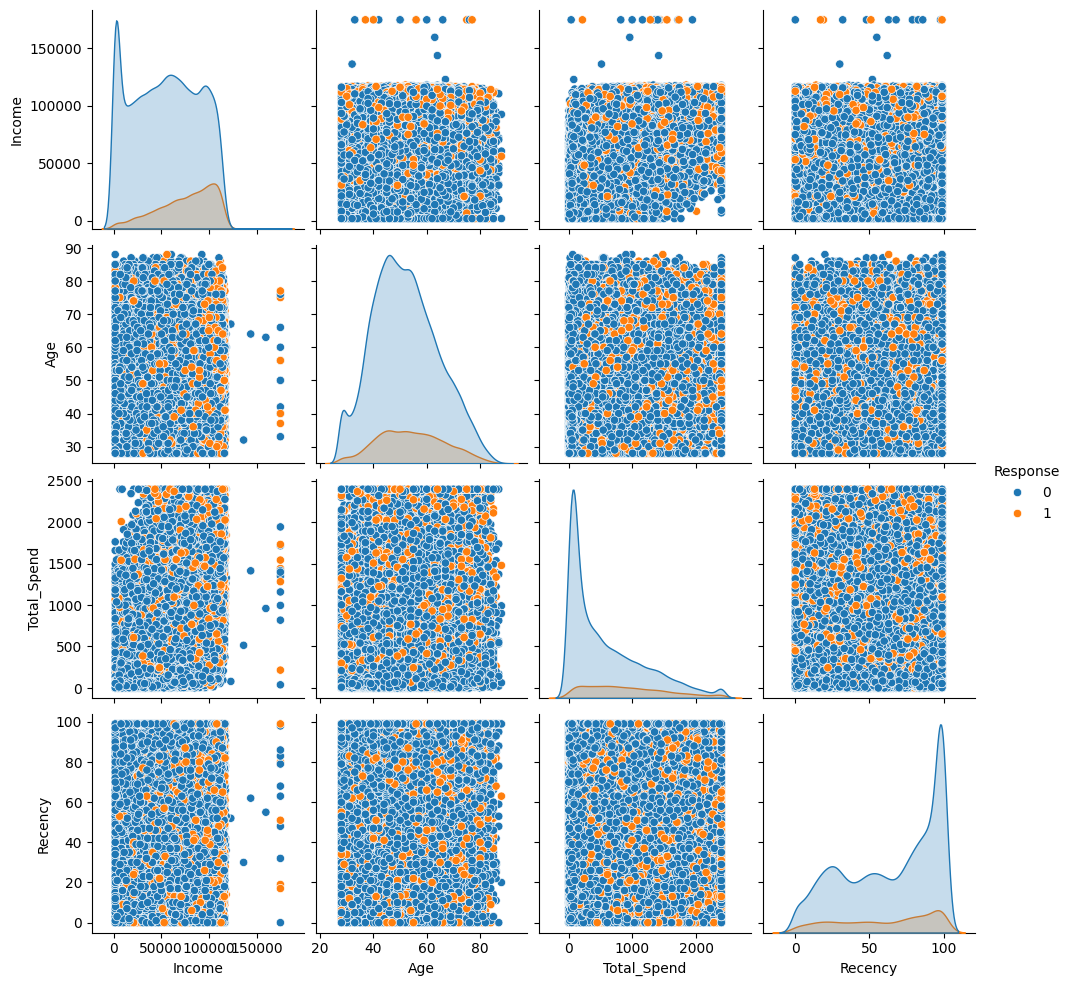

In [46]:
#Pairplot (Deep relationship view)
sns.pairplot(
    df[['Income','Age','Total_Spend','Recency','Response']],
    hue='Response'
)
plt.show()

FINAL REPORT SUMMARY

Univariate Insights
Income is right-skewed with high outliers
Majority customers are middle-aged
Most customers are low-frequency buyers
Campaign response is highly imbalanced


Bivariate Insights
High income customers respond more
High spenders have higher response rate
Recently active customers convert better
More children reduces spending behavior

Multivariate Insights
Income + Spending strongly define customer value
Web engagement improves conversion probability
Purchase behavior + recency together predict response
Clear separation exists between responders and non-responders

In [47]:
df.shape

(56000, 54)

In [48]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Response', 'Complain', 'Country', 'Age', 'Total_Spend',
       'Total_Purchases', 'Children', 'Age_Group', 'Family_Size',
       'Living_With', 'Customer_Tenure', 'Total_Accepted_Campaigns',
       'Customer_Segment', 'Purchase_Frequency', 'Web_Engagement', 'Is_Parent',
       'Income_Group', 'Engagement_Segment', 'Spending_Segment',
       'Response_Segment', 'Family_Segment', 'High_Value', 'Under_Served',
       'Deal_Seeker', 'Loyal_Customer', 'At_Risk', 'New_Customer', 'Year',
       'Month'],
      dtype='object')

In [49]:
df.isnull().sum()

ID                          0
Year_Birth                  0
Education                   0
Marital_Status              0
Income                      0
Kidhome                     0
Teenhome                    0
Dt_Customer                 0
Recency                     0
MntWines                    0
MntFruits                   0
MntMeatProducts             0
MntFishProducts             0
MntSweetProducts            0
MntGoldProds                0
NumDealsPurchases           0
NumWebPurchases             0
NumCatalogPurchases         0
NumStorePurchases           0
NumWebVisitsMonth           0
AcceptedCmp3                0
AcceptedCmp4                0
AcceptedCmp5                0
AcceptedCmp1                0
AcceptedCmp2                0
Response                    0
Complain                    0
Country                     0
Age                         0
Total_Spend                 0
Total_Purchases             0
Children                    0
Age_Group                   0
Family_Siz

In [52]:
df.to_csv("../data/EDA_Analysis.csv", index=False)

In [ ]:
df.co